# Imports

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
from scipy import ndimage as ndi
from skimage import io
from skimage import transform

import nibabel as nib

import torch
from torch.utils.data import Dataset

import pytorch_lightning as pl

import monai.transforms as T
from monai.data import CacheDataset, DataLoader

# Patch Subsampling

## Slicing functions

In [2]:
def slicing_trn(img, msk, resize_to):
    
    # Subsampling.
    y_stride = (img.shape[0] // resize_to[0]) + 1
    x_stride = (img.shape[1] // resize_to[1]) + 1
    z_stride = (img.shape[2] // resize_to[2]) + 1
    
    y_off = np.random.randint(y_stride)
    x_off = np.random.randint(x_stride)
    z_off = np.random.randint(z_stride)
    
    img = img[y_off::y_stride, x_off::x_stride, z_off::z_stride]
    msk = msk[y_off::y_stride, x_off::x_stride, z_off::z_stride]
    
    # Resizing.
    before_crop_size = (resize_to[0] + (resize_to[0] // 8),
                        resize_to[1] + (resize_to[1] // 8),
                        resize_to[2] + (resize_to[2] // 8))
    
    img = transform.resize(img, before_crop_size, order=1, preserve_range=True, anti_aliasing=False)
    msk = transform.resize(msk, before_crop_size, order=0, preserve_range=True, anti_aliasing=False)
    
    # Random crop to size resize_to.
    rnd_crop = (np.random.randint(low=0, high=(before_crop_size[0] - resize_to[0])),
                np.random.randint(low=0, high=(before_crop_size[1] - resize_to[1])),
                np.random.randint(low=0, high=(before_crop_size[2] - resize_to[2])))
    
    img = img[rnd_crop[0]:(rnd_crop[0] + resize_to[0]),
              rnd_crop[1]:(rnd_crop[1] + resize_to[1]),
              rnd_crop[2]:(rnd_crop[2] + resize_to[2])]
    msk = msk[rnd_crop[0]:(rnd_crop[0] + resize_to[0]),
              rnd_crop[1]:(rnd_crop[1] + resize_to[1]),
              rnd_crop[2]:(rnd_crop[2] + resize_to[2])]
    
    # Randomly flipping image on axis 1.
    if np.random.random() > 0.5:
        img = np.flip(img, axis=1)
        msk = np.flip(msk, axis=1)
    
    # Randomly rotating the volume for a few degrees across the axial plane.
    angle = np.random.randn()
    img = ndi.rotate(img, angle, axes=(0, 1), order=1, reshape=False)
    msk = ndi.rotate(msk, angle, axes=(0, 1), order=0, reshape=False)
    
    return img, msk

In [3]:
def slicing_tst(img, msk, resize_to):

    img_list = []
    msk_list = []
    off_list = []
    patch_size_list = []

    y_stride = (img.shape[0] // resize_to[0]) + 1
    x_stride = (img.shape[1] // resize_to[1]) + 1
    z_stride = (img.shape[2] // resize_to[2]) + 1

    strides = (y_stride, x_stride, z_stride)

    for y_off in range(y_stride):
        for x_off in range(x_stride):
            for z_off in range(z_stride):

                img_crop = img[y_off::y_stride,
                               x_off::x_stride,
                               z_off::z_stride]
                msk_crop = msk[y_off::y_stride,
                               x_off::x_stride,
                               z_off::z_stride]

                crop_shape = img_crop.shape
                img_crop = transform.resize(img_crop, resize_to, order=1, preserve_range=True, anti_aliasing=False)
                msk_crop = transform.resize(msk_crop, resize_to, order=0, preserve_range=True, anti_aliasing=False)

                img_crop = img_crop.astype(np.float32)
                msk_crop = msk_crop.astype(np.int64)

                img_crop = np.expand_dims(img_crop, 0)

                img_crop = torch.from_numpy(img_crop)
                msk_crop = torch.from_numpy(msk_crop)

                img_list.append(img_crop)
                msk_list.append(msk_crop)
                off_list.append((y_off, x_off, z_off))
                patch_size_list.append(crop_shape)

    return img_list, msk_list, off_list, patch_size_list, strides

## Sticthing function

In [4]:
def sticthing_tst(net, inps_list, labs_list, off_list, size_list, strides, orig_shape):

    orig_shape = (orig_shape[0].item(),
                  orig_shape[1].item(),
                  orig_shape[2].item())

    inps_full = np.zeros(orig_shape, dtype=np.float32)
    labs_full = np.zeros(orig_shape, dtype=np.uint8)
    prds_full = np.zeros(orig_shape, dtype=np.uint8)

    for inps, labs, off, sz in zip(inps_list, labs_list, off_list, size_list):

        sz = (sz[0].item(),
              sz[1].item(),
              sz[2].item())

        # Casting tensors to cuda.
        inps = inps.cuda()
        labs = labs.cuda()

        # Forwarding.
        outs = net(inps)

        # Obtaining predictions.
        prds = outs.detach().max(1)[1].squeeze().cpu().numpy()

        # Transforming to ndarray.
        inps = inps.detach().squeeze().cpu().numpy()
        labs = labs.detach().squeeze().cpu().numpy()

        # Reconstructing full sample, mask and prediction.
        inps = transform.resize(inps, sz, order=1, preserve_range=True, anti_aliasing=False)
        labs = transform.resize(labs, sz, order=0, preserve_range=True, anti_aliasing=False).astype(np.uint8)
        prds = transform.resize(prds, sz, order=0, preserve_range=True, anti_aliasing=False).astype(np.uint8)

        inps_full[off[0]::strides[0],
                  off[1]::strides[1],
                  off[2]::strides[2]] = inps
        labs_full[off[0]::strides[0],
                  off[1]::strides[1],
                  off[2]::strides[2]] = labs
        prds_full[off[0]::strides[0],
                  off[1]::strides[1],
                  off[2]::strides[2]] = prds
        
    return inps_full, labs_full, prds_full

## Dataset

In [5]:
class Dataset(Dataset):
    
    def __init__(self, mode, dataset_path, fold_id, transform, resize_to, cache_rate, num_workers):

        super().__init__()
        
        self.mode = mode
        
        self.dataset_path = dataset_path
        self.fold_id = fold_id
        
        self.image_folder = os.path.join(self.dataset_path, 'images')
        self.mask_folder = os.path.join(self.dataset_path, 'ground_truths')
        self.folds_folder = os.path.join(self.dataset_path, 'folds')

        self.transform = transform
        self.resize_to = resize_to

        # Creating the dataset list
        self.imgs = self.make_dataset()

        # super().__init__(data=self.imgs, transform=transform, cache_rate=cache_rate, num_workers=num_workers)
                
    def make_dataset(self):

        image_paths = [os.path.join(self.image_folder, f) for f in os.listdir(self.image_folder) if f.endswith(".nii.gz")]
        mask_paths = [os.path.join(self.mask_folder, f) for f in os.listdir(self.mask_folder) if f.endswith(".nii.gz")]

        image_paths.sort()
        mask_paths.sort()
        
        if self.mode == 'train':
            prefix = 'trn'
        elif self.mode in ['val', 'test']:
            prefix = 'tst'
        
        fold_path = os.path.join(self.folds_folder, f'{prefix}_f{self.fold_id}.txt')
        
        def get_ids_from_file(file_path):
            with open(file_path) as file:
                lines = [line.strip() for line in file if line.strip()]
            return lines
        
        ids = get_ids_from_file(fold_path)
        
        img_paths = [p for p in image_paths if os.path.basename(p) in ids]
        mask_paths = [p for p in mask_paths if os.path.basename(p) in ids]
        
        assert len(img_paths) == len(mask_paths)
        
        files = [{"image": img, "mask": msk} for img, msk in zip(img_paths, mask_paths)]

        return files

    def __getitem__(self, index):
        
        # data = super().__getitem__(index)

        data = self.transform(self.imgs[index])

        img = data['image']
        msk = data['mask']

        # Train and test transformations
        if self.mode == 'train':

            # Slicing for train.
            img, msk = slicing_trn(img, msk, self.resize_to)
            
            # Casting image and mask to the appropriate dtypes.
            img = img.astype(np.float32)
            msk = msk.astype(np.int64)
            
            # # Adding channel dimension.
            img = np.expand_dims(img, axis=0)
            
            # Turning to tensors.
            img = torch.from_numpy(img)
            msk = torch.from_numpy(msk)
            
            return img, msk, self.imgs[index]['image'].split('/')[-1]
        
        elif self.mode in ['val', 'test']:

            # Saving original size.
            orig_shape = img.shape
            
            # Slicing.
            img, msk, off, size, strides = slicing_tst(img, msk, self.resize_to)
            
            return img, msk, off, size, strides, orig_shape, self.imgs[index]['image'].split('/')[-1]

    def __len__(self):
        return len(self.imgs)

## Datamodule

In [6]:
class PatchSubsamplingDataModule(pl.LightningDataModule):
    
    def __init__(self, dataset_path, fold_id, batch_size, num_workers, train_transforms, val_transforms, resize_to):
        
        super().__init__()
        
        self.dataset_path = dataset_path
        self.fold_id = fold_id
     
        self.batch_size = batch_size
        self.num_workers = num_workers
        
        self.train_transforms = train_transforms
        self.val_transforms = val_transforms

        self.resize_to = resize_to

    def setup(self, stage='none'):
        
        self.train_dataset = Dataset(
            mode='train',
            dataset_path=self.dataset_path,
            fold_id=self.fold_id,
            transform=self.train_transforms,
            resize_to=self.resize_to,
            cache_rate=1.0,
            num_workers=self.num_workers
        )
        
        self.val_dataset = Dataset(
            mode='val',
            dataset_path=self.dataset_path,
            fold_id=self.fold_id,
            transform=self.val_transforms,
            resize_to=self.resize_to,
            cache_rate=1.0,
            num_workers=self.num_workers
        )
       
    def train_dataloader(self):
        return DataLoader(self.train_dataset, batch_size=self.batch_size, shuffle=True, num_workers=self.num_workers)

    def val_dataloader(self):
        return DataLoader(self.val_dataset, batch_size=1, shuffle=False, num_workers=self.num_workers)


# Code test

## Checking device

In [7]:
print('CUDA available?', torch.cuda.is_available())
print('Current device:', torch.cuda.current_device())
print('Device name:', torch.cuda.get_device_name(0))

CUDA available? True
Current device: 0
Device name: NVIDIA GeForce RTX 4090


## Set seed 

In [8]:
pl.seed_everything(42, workers=True)

Seed set to 42


42

## Set configs

In [9]:
dataset = 'structseg_thorax'
dataset_path = f'../../data/datasets/{dataset}_patch'
resize_to = (128, 128, 128)
batch_size = 2
num_workers = 0

## Debug

In [10]:
hu_range = {
    'structseg_thorax': [-310, 400],
    'multiorgan_ct_btcv': [-1000, 1000],
    'structseg_head': [-200, 700],
}

a_min = hu_range[dataset][0]
a_max = hu_range[dataset][1]

train_transforms = T.Compose([
    T.LoadImaged(keys=['image', 'mask']),

    T.ScaleIntensityRanged(
        keys=['image'],
        a_min=a_min, a_max=a_max,
        b_min=0.0, b_max=1.0,
        clip=True
    ),

    T.ToNumpyd(keys=['image', 'mask'])
])

val_transforms = T.Compose([
    T.LoadImaged(keys=['image', 'mask']),
    
    T.ScaleIntensityRanged(
        keys=['image'],
        a_min=a_min, a_max=a_max,
        b_min=0.0, b_max=1.0,
        clip=True
    ),

    T.ToNumpyd(keys=['image', 'mask'])
])

In [11]:
datamodule = PatchSubsamplingDataModule(
    
    dataset_path=dataset_path, 
    fold_id=0, 
    batch_size=batch_size, 
    num_workers=0,
    train_transforms=train_transforms,
    val_transforms=val_transforms,
    resize_to=resize_to
)

datamodule.setup()

In [12]:
train_loader = datamodule.train_dataloader()
train_batch = next(iter(train_loader))

train_imgs, train_msks, train_ids = train_batch
print(f"Shape do batch de imagens (Treino): {train_imgs.shape}") # Esperado: (Batch, 1, 128, 128, 128)
print(f"Shape do batch de máscaras (Treino): {train_msks.shape}") 
print(f"IDs das amostras: {train_ids}")

Shape do batch de imagens (Treino): torch.Size([2, 1, 128, 128, 128])
Shape do batch de máscaras (Treino): torch.Size([2, 128, 128, 128])
IDs das amostras: ('2.nii.gz', '27.nii.gz')


In [13]:
test_loader = datamodule.val_dataloader()
test_batch = next(iter(test_loader))

inps_list, labs_list, off_list, size_list, strides, orig_shape, sample_id = test_batch

print(f"ID da amostra de teste: {sample_id[0]}")
print(f"Shape original do volume: {[s.item() for s in orig_shape]}")
print(f"Quantidade de patches gerados para este volume: {len(inps_list)}")

ID da amostra de teste: 1.nii.gz
Shape original do volume: [482, 282, 476]
Quantidade de patches gerados para este volume: 48


In [14]:
class TestNet(torch.nn.Module):
    def forward(self, x):

        b, c, h, w, d = x.shape

        return torch.zeros((b, 2, h, w, d), device=x.device)

net = TestNet().cuda()

In [15]:
inps_full, labs_full, prds_full = sticthing_tst(
    net=net,
    inps_list=inps_list, 
    labs_list=labs_list,
    off_list=off_list,
    size_list=size_list,
    strides=strides,
    orig_shape=orig_shape
)

print(f"Shape final reconstruído: {inps_full.shape}")

Shape final reconstruído: (482, 282, 476)


Text(0.5, 1.0, 'Patch 0 (Grid) Teste\n(128, 128, 128)')

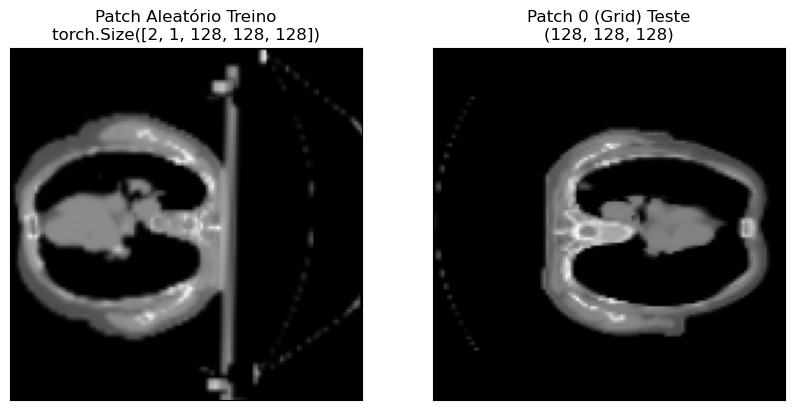

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(10, 10))

ax[0].imshow(train_imgs[0, 0, :, :, int(0.50 * train_imgs.shape[2])].numpy(), cmap='gray')
ax[0].set_yticks([])
ax[0].set_xticks([])
ax[0].set_title(f"Patch Aleatório Treino\n{train_imgs.shape}")

patch_test_0 = inps_list[0].squeeze().numpy()
ax[1].imshow(patch_test_0[:, :, int(0.50 * patch_test_0.shape[2])], cmap='gray')
ax[1].set_yticks([])
ax[1].set_xticks([])
ax[1].set_title(f"Patch 0 (Grid) Teste\n{patch_test_0.shape}")

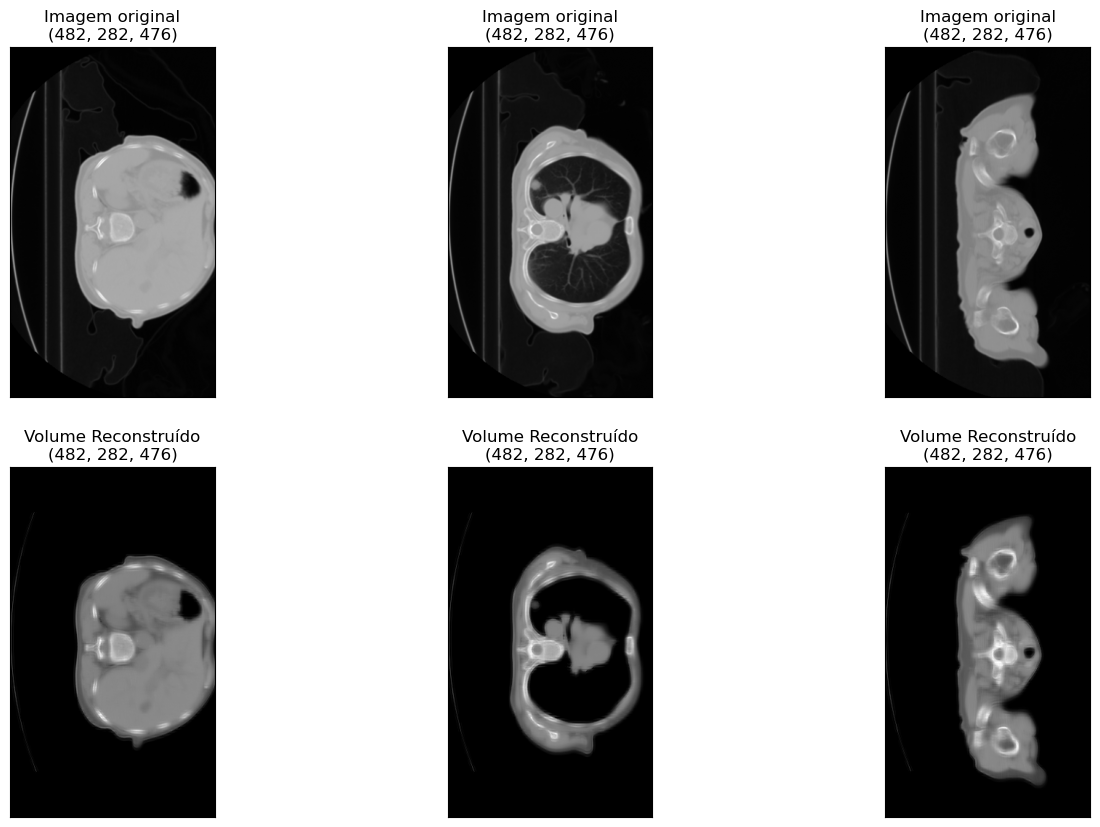

In [17]:
img = nib.load(os.path.join(dataset_path, f'images/{sample_id[0]}')).get_fdata()

fig, ax = plt.subplots(2, 3, figsize=(16, 10))

ax[0, 0].imshow(img[:, :, int(0.25 * img.shape[2])], cmap='gray')
ax[0, 0].set_yticks([])
ax[0, 0].set_xticks([])
ax[0, 0].set_title(f'Imagem original\n{img.shape}')

ax[0, 1].imshow(img[:, :, int(0.50 * img.shape[2])], cmap='gray')
ax[0, 1].set_yticks([])
ax[0, 1].set_xticks([])
ax[0, 1].set_title(f'Imagem original\n{img.shape}')

ax[0, 2].imshow(img[:, :, int(0.75 * img.shape[2])], cmap='gray')
ax[0, 2].set_yticks([])
ax[0, 2].set_xticks([])
ax[0, 2].set_title(f'Imagem original\n{img.shape}')

ax[1, 0].imshow(inps_full[:, :, int(0.25 * inps_full.shape[2])], cmap='gray')
ax[1, 0].set_yticks([])
ax[1, 0].set_xticks([])
ax[1, 0].set_title(f'Volume Reconstruído\n{inps_full.shape}')

ax[1, 1].imshow(inps_full[:, :, int(0.50 * inps_full.shape[2])], cmap='gray')
ax[1, 1].set_yticks([])
ax[1, 1].set_xticks([])
ax[1, 1].set_title(f'Volume Reconstruído\n{inps_full.shape}')

ax[1, 2].imshow(inps_full[:, :, int(0.75 * inps_full.shape[2])], cmap='gray')
ax[1, 2].set_yticks([])
ax[1, 2].set_xticks([])
ax[1, 2].set_title(f'Volume Reconstruído\n{inps_full.shape}')

plt.show()